# EDA Part 1 (ml.m5.2xlarge)

In [1]:
import os
import pandas as pd
import numpy as np
import functions as func

### Constants

In [2]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_step = os.getcwd().split('/')[-1]
print(f'Step: {str_step}')
str_dirname_output = './output'
str_variant = 'noPTImodel10'

str_id = 'uniqueid__app'
str_datecol = 'applicationdate__app'

list_cols_id = [
#     str_id,
#     str_datecol,
#     str_target,
]

Project: 20231010-gen-xii
Step: 03_eda


### Output

In [3]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Variant directory

In [4]:
try:
    os.mkdir(f'{str_dirname_output}/{str_variant}')
except:
    pass

### Import data

In [5]:
%%time

# import
str_filename = 'df_pd_pre_with_yhats.gzip'
str_uri = f's3://{str_project}/ad_hoc/get_predictions/{str_variant}/{str_filename}'
# read from s3
df = pd.read_parquet(str_uri)

# subset
df = df[df['data_set'] == 'test']

# show
df

CPU times: user 7.55 s, sys: 3.15 s, total: 10.7 s
Wall time: 2.61 s


,bigaccountid__app,linkf060__tu,linkf045__tu,linkf079__tu,linkf185__tu,linkf105__tu,linkf195__tu,linkf193__tu,linkb012__tu,linkf032__tu,...,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,yhat_ad,yhat_pricing_pd,yhat_pricing_lgd
12401,3932700.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,...,1.165459,10,4,0.09,1.282051,1.0,5.879452,0.265997,0.208567,0.619272
26947,3932720.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,...,1.165459,10,4,0.06,1.322581,3.0,6.441096,0.466850,0.147658,0.638730
26946,3932720.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,...,1.165459,10,4,0.06,1.322581,3.0,6.441096,0.475868,0.158812,0.638730
16514,3932724.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,...,1.165459,10,4,0.15,1.195652,1.0,6.736986,0.264749,0.203020,0.607942
16515,3932724.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,...,1.165459,10,4,0.15,1.195652,1.0,6.736986,0.259356,0.191142,0.607942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7864,4812498.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,...,1.144717,12,4,0.09,1.548387,2.0,10.010959,0.336901,0.145701,0.592475
7863,4812498.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nan,...,1.144717,12,4,0.09,1.548387,2.0,10.010959,0.343272,0.153010,0.592475
20360,4812503.0,0.0,0.0,0.0,1182.0,1182.0,1182.0,1182.0,0.0,n,...,1.144717,12,4,0.12,1.044444,-1.0,0.208219,0.341951,0.118688,0.689688
20361,4812503.0,0.0,0.0,0.0,1182.0,1182.0,1182.0,1182.0,0.0,n,...,1.144717,12,4,0.12,1.044444,-1.0,0.208219,0.332062,0.104094,0.689688


### Get descriptives

In [6]:
%%time

str_filename = 'df_descriptives.csv'
list_cols = [col for col in df.columns if col not in list_cols_id]
df_tmp = func.get_descriptives_by_column(
    df=df[list_cols], 
    str_dirname_output=f'{str_dirname_output}/{str_variant}', 
    str_filename=str_filename,
)

# show
df_tmp

# save memory
del df_tmp

100%|██████████| 1592/1592 [00:07<00:00, 224.40it/s]

CPU times: user 7.23 s, sys: 505 ms, total: 7.73 s
Wall time: 7.29 s


### Get descriptives by ID columns

In [7]:
%%time

try:
    str_filename = 'df_descriptives_id.csv',
    df_tmp = func.get_descriptives_by_column(
        df=df[list_cols_id], 
        str_dirname_output=f'{str_dirname_output}/{str_variant}', 
        str_filename=str_filename,
    )

    # show
    df_tmp

    # save memory
    del df_tmp
except:
    pass

0it [00:00, ?it/s]

CPU times: user 4.04 ms, sys: 4 µs, total: 4.04 ms
Wall time: 3.07 ms


### Plot proportion ```NaN```

CPU times: user 174 ms, sys: 12.3 ms, total: 186 ms
Wall time: 208 ms


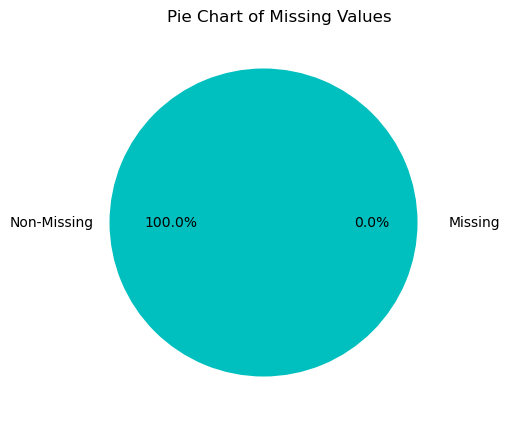

In [8]:
%%time

# plot proportion NaN
try:
    str_filename = 'plt_prop_nan.png',
    func.plot_proportion_nan(
        df=df,
        str_dirname_output=f'{str_dirname_output}/{str_variant}',
        str_filename=str_filename,
    )
except:
    pass

### Plot data type frequency

100%|██████████| 1592/1592 [00:00<00:00, 46078.21it/s]


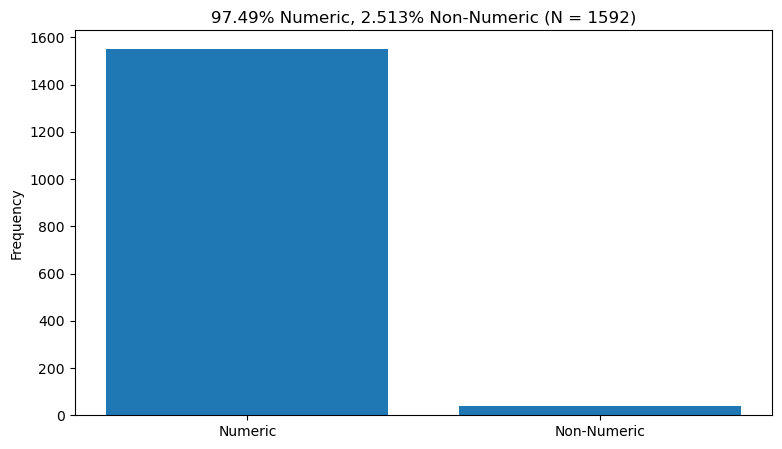

CPU times: user 295 ms, sys: 11.6 ms, total: 307 ms
Wall time: 305 ms


In [9]:
%%time

# plot data type frequency
str_filename = 'plt_dtype.png'
func.plot_data_type_frequency(
    df=df,
    str_dirname_output=f'{str_dirname_output}/{str_variant}',
    str_filename=str_filename,
)